# 02.6 - Information Theory

**Phase:** 02 - Mathematics for ML

**Status:** VERIFIED

---

## 1. What Are We Solving?

Information theory quantifies **information** and **uncertainty**. It gives us the mathematical tools to measure how much a random variable tells us, how different two probability distributions are, and how to design efficient codes. In ML, it directly produces the **cross-entropy loss** used in classification and the **KL divergence** used in variational methods.

## 2. Why Does This Matter?

Cross-entropy is the default loss function for classification. KL divergence is central to generative models (VAEs), Bayesian inference, and model compression. Understanding information theory explains *why* these loss functions work.

## 3. Prerequisites

- Unit 02.5 (Probability)

## 4. Learning Objectives

By the end of this notebook, you should be able to:
- Define self-information and entropy
- Compute entropy of a distribution
- Understand cross-entropy and why it's a loss function
- Understand KL divergence and how it measures distribution difference
- Connect these to machine learning loss functions

## 5. Mental Model

**Information** is about surprise: a rare event carries more information than a common one. **Entropy** is the average amount of surprise (uncertainty) in a distribution. **Cross-entropy** measures how many bits are needed to encode data from one distribution using a code optimized for another. **KL divergence** is the extra cost of using the wrong distribution - it's always non-negative and zero only when the distributions match.


## 6. Self-Information

The **self-information** of an event with probability `p` is:

`I(x) = -log2(p(x))`

A certain event (p=1) carries 0 bits of information. A rare event (p small) carries many bits.


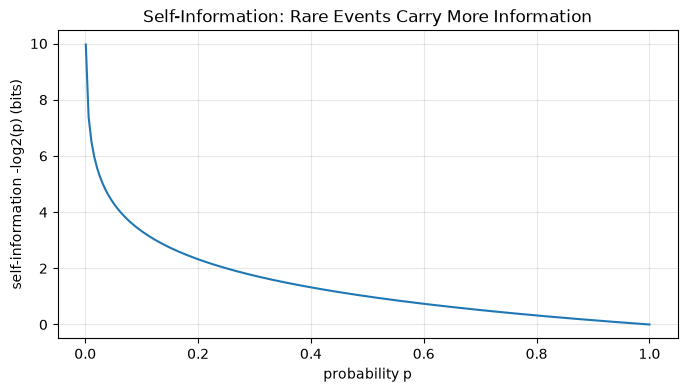

p=1.0  -> -0.00 bits (certain, no info)
p=0.5  -> 1.00 bits (fair coin)
p=0.1  -> 3.32 bits (rare)
p=0.01 -> 6.64 bits (very rare)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Self-information: -log2(p)
p = np.linspace(0.001, 1, 200)
info = -np.log2(p)

plt.figure(figsize=(8, 4))
plt.plot(p, info)
plt.xlabel("probability p")
plt.ylabel("self-information -log2(p) (bits)")
plt.title("Self-Information: Rare Events Carry More Information")
plt.grid(True, alpha=0.3)
plt.show()

print(f"p=1.0  -> {(-np.log2(1.0)):.2f} bits (certain, no info)")
print(f"p=0.5  -> {(-np.log2(0.5)):.2f} bits (fair coin)")
print(f"p=0.1  -> {(-np.log2(0.1)):.2f} bits (rare)")
print(f"p=0.01 -> {(-np.log2(0.01)):.2f} bits (very rare)")


## 7. Entropy

**Entropy** is the expected (average) self-information of a distribution:

`H(X) = -sum(p(x) * log2(p(x)))`

It measures the **uncertainty** of a random variable. A fair coin (p=0.5) has entropy 1 bit. A biased coin has less entropy (more predictable).


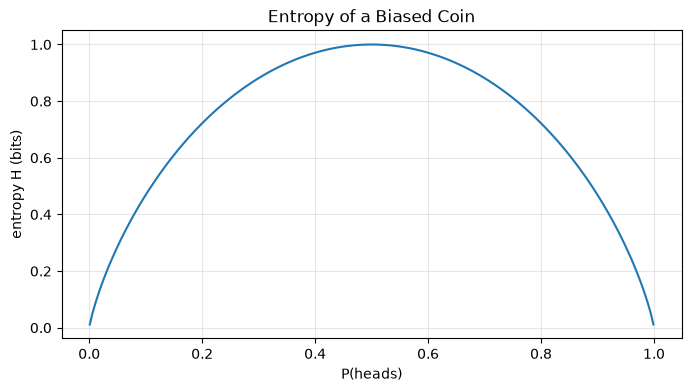

Fair coin (p=0.5): H = 1.0000 bits (maximum)
Biased coin (p=0.9): H = 0.4690 bits
Certain (p=1.0): H = 0.0000 bits (minimum)

Entropy is maximized when outcomes are equally likely (maximum uncertainty).


In [2]:
# Entropy of a coin with varying bias
def entropy(p):
    p = np.clip(p, 1e-12, 1)  # avoid log(0)
    return -np.sum(p * np.log2(p))

p_heads = np.linspace(0.001, 0.999, 200)
H = [entropy([p, 1 - p]) for p in p_heads]

plt.figure(figsize=(8, 4))
plt.plot(p_heads, H)
plt.xlabel("P(heads)")
plt.ylabel("entropy H (bits)")
plt.title("Entropy of a Biased Coin")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Fair coin (p=0.5): H = {entropy([0.5, 0.5]):.4f} bits (maximum)")
print(f"Biased coin (p=0.9): H = {entropy([0.9, 0.1]):.4f} bits")
print(f"Certain (p=1.0): H = {entropy([1.0, 0.0]):.4f} bits (minimum)")
print("\nEntropy is maximized when outcomes are equally likely (maximum uncertainty).")


## 8. Cross-Entropy

**Cross-entropy** between a true distribution `p` and a predicted distribution `q` is:

`H(p, q) = -sum(p(x) * log2(q(x)))`

It measures the average number of bits needed to encode events from `p` using a code optimized for `q`. It's always `>= H(p)`, with equality when `p == q`.

In ML classification, `p` is the one-hot true label and `q` is the model's predicted probability. Minimizing cross-entropy is equivalent to maximizing the likelihood of the correct class.


In [3]:
# Cross-entropy for a 3-class classification problem
def cross_entropy(p, q):
    q = np.clip(q, 1e-12, 1)
    return -np.sum(p * np.log2(q))

# True label: class 1 (one-hot)
p_true = np.array([0.0, 1.0, 0.0])

# Good prediction: model is confident about class 1
q_good = np.array([0.05, 0.90, 0.05])
# Bad prediction: model is confident about the WRONG class
q_bad = np.array([0.90, 0.05, 0.05])
# Uncertain prediction: model is unsure
q_uncertain = np.array([0.33, 0.34, 0.33])

print(f"Good prediction:      CE = {cross_entropy(p_true, q_good):.4f} bits")
print(f"Uncertain prediction: CE = {cross_entropy(p_true, q_uncertain):.4f} bits")
print(f"Bad prediction:       CE = {cross_entropy(p_true, q_bad):.4f} bits")
print("\nLower cross-entropy = better prediction. The bad prediction has the highest CE.")


Good prediction:      CE = 0.1520 bits
Uncertain prediction: CE = 1.5564 bits
Bad prediction:       CE = 4.3219 bits

Lower cross-entropy = better prediction. The bad prediction has the highest CE.


## 9. KL Divergence

**KL divergence** measures how one distribution `q` differs from another `p`:

`KL(p || q) = sum(p(x) * log2(p(x) / q(x)))`

It equals `H(p, q) - H(p)`: the extra bits needed because we used `q` instead of `p`. Key properties:

- `KL(p || q) >= 0` always (Gibbs' inequality)
- `KL(p || q) = 0` iff `p == q`
- It is **not symmetric**: `KL(p || q) != KL(q || p)`

Note: `KL(p || q) = H(p, q) - H(p)`, so minimizing cross-entropy with fixed `p` is equivalent to minimizing KL divergence.


In [4]:
# KL divergence
def kl(p, q):
    p = np.clip(p, 1e-12, 1)
    q = np.clip(q, 1e-12, 1)
    return np.sum(p * np.log2(p / q))

# Two similar distributions
p = np.array([0.5, 0.5])
q_similar = np.array([0.55, 0.45])
q_different = np.array([0.9, 0.1])

print(f"KL(p || q_similar)    = {kl(p, q_similar):.4f} bits")
print(f"KL(p || q_different)  = {kl(p, q_different):.4f} bits")
print(f"KL(p || p)            = {kl(p, p):.4f} bits (zero when identical)")

# KL is NOT symmetric
print(f"\nKL(p || q_different)  = {kl(p, q_different):.4f}")
print(f"KL(q_different || p)  = {kl(q_different, p):.4f}")
print(f"Symmetric? {abs(kl(p, q_different) - kl(q_different, p)) < 1e-6}")


KL(p || q_similar)    = 0.0072 bits
KL(p || q_different)  = 0.7370 bits
KL(p || p)            = 0.0000 bits (zero when identical)

KL(p || q_different)  = 0.7370
KL(q_different || p)  = 0.5310
Symmetric? False


## 10. Cross-Entropy as a Loss Function

In classification, we minimize cross-entropy between the true labels and predictions. Let's see how it behaves as a loss during training - it should decrease as predictions improve.


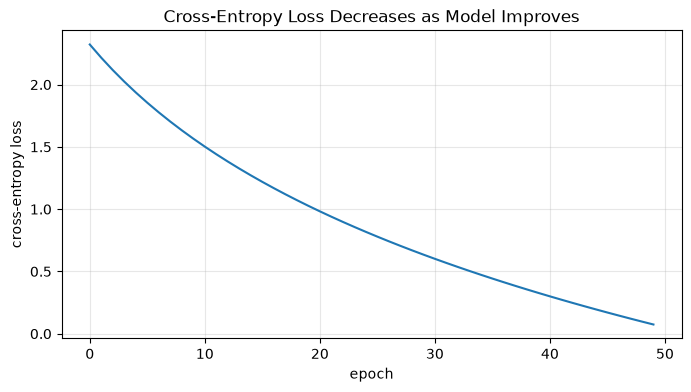

Early (p=0.2): CE = 2.3219
Late  (p=0.95): CE = 0.0740

As the model becomes more confident about the correct class,
cross-entropy loss decreases toward 0.


In [5]:
# Cross-entropy loss during a simulated training run
np.random.seed(42)

# Simulate a model's predicted probability for the correct class improving over epochs
n_epochs = 50
p_correct = np.linspace(0.2, 0.95, n_epochs)  # improving confidence

# Cross-entropy for a 2-class problem where true class is 0
# CE = -log2(p_correct)
ce_loss = -np.log2(p_correct)

plt.figure(figsize=(8, 4))
plt.plot(np.arange(n_epochs), ce_loss)
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.title("Cross-Entropy Loss Decreases as Model Improves")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Early (p=0.2): CE = {ce_loss[0]:.4f}")
print(f"Late  (p=0.95): CE = {ce_loss[-1]:.4f}")
print("\nAs the model becomes more confident about the correct class,")
print("cross-entropy loss decreases toward 0.")


## 11. Failure Case: log(0)

A classic failure: if the model assigns probability 0 to the true class, `log(0)` is `-inf`, and cross-entropy becomes infinite. This is why we **clip** probabilities to a small epsilon (e.g. `1e-12`) before taking the log.


In [6]:
# Failure case: log(0) gives -inf
p_true = np.array([0.0, 1.0, 0.0])
q_zero = np.array([0.0, 0.0, 1.0])  # model assigns 0 probability to true class

try:
    ce = -np.sum(p_true * np.log2(q_zero))
    print(f"Cross-entropy: {ce}")
except Exception as e:
    print(f"Error: {e}")

# Fix: clip probabilities
q_clipped = np.clip(q_zero, 1e-12, 1)
ce_fixed = -np.sum(p_true * np.log2(q_clipped))
print(f"\nWith clipping: CE = {ce_fixed:.4f} (large but finite)")
print("Clipping prevents -inf and keeps gradients finite.")


Cross-entropy: nan

With clipping: CE = 39.8631 (large but finite)
Clipping prevents -inf and keeps gradients finite.


C:\Users\PC\AppData\Local\Temp\ipykernel_1444\3368773447.py:6: RuntimeWarning: divide by zero encountered in log2
  ce = -np.sum(p_true * np.log2(q_zero))
C:\Users\PC\AppData\Local\Temp\ipykernel_1444\3368773447.py:6: RuntimeWarning: invalid value encountered in multiply
  ce = -np.sum(p_true * np.log2(q_zero))


## 12. Debugging: Common Errors

- **log(0) / -inf loss**: clip probabilities to a small epsilon.
- **Using natural log vs log2**: the base only changes the units (nats vs bits); be consistent.
- **Forgetting to normalize q**: cross-entropy assumes `q` is a valid probability distribution (sums to 1).
- **Confusing cross-entropy and KL**: `KL(p||q) = H(p,q) - H(p)`. When `p` is fixed (as in supervised learning), minimizing CE == minimizing KL.

## 13. Real-World Considerations

- **Cross-entropy loss** is the default for classification in PyTorch/TensorFlow (`nn.CrossEntropyLoss`).
- **KL divergence** is used in VAEs (variational autoencoders) to regularize the latent space.
- **Log-likelihood**: maximizing log-likelihood is equivalent to minimizing cross-entropy.
- **Label smoothing**: replaces hard one-hot targets with soft targets to improve generalization - it's a form of regularization on the cross-entropy loss.

## 14. Common Mistakes

- Not clipping probabilities before taking logs.
- Assuming KL divergence is symmetric (it is not).
- Using cross-entropy for regression (use MSE instead).
- Forgetting that entropy is maximized for uniform distributions.

## 15. When NOT to Use

- Don't use cross-entropy for regression tasks - use MSE or MAE.
- Don't use KL divergence when you need a true distance metric (it's not symmetric and doesn't satisfy the triangle inequality).

## 16. Challenge

Compute the cross-entropy and KL divergence between a true distribution `p = [0.7, 0.2, 0.1]` and a predicted distribution `q = [0.6, 0.3, 0.1]`. Verify that `KL(p||q) == H(p,q) - H(p)`.


In [7]:
# Challenge: cross-entropy and KL divergence
p = np.array([0.7, 0.2, 0.1])
q = np.array([0.6, 0.3, 0.1])

H_p = entropy(p)
H_pq = cross_entropy(p, q)
KL_pq = kl(p, q)

print(f"H(p)      = {H_p:.4f}")
print(f"H(p, q)   = {H_pq:.4f}")
print(f"KL(p||q)  = {KL_pq:.4f}")
print(f"H(p,q)-H(p) = {H_pq - H_p:.4f}")
print(f"KL == H(p,q)-H(p): {abs(KL_pq - (H_pq - H_p)) < 1e-9}")


H(p)      = 1.1568
H(p, q)   = 1.1955
KL(p||q)  = 0.0387
H(p,q)-H(p) = 0.0387
KL == H(p,q)-H(p): True


## 17. Closed-Book Recall

Without looking back:

1. What is self-information and why do rare events carry more of it?
2. Write the formula for entropy.
3. What is cross-entropy and why is it used as a classification loss?
4. What is KL divergence and what are its key properties?
5. How are cross-entropy and KL divergence related?

## 18. Teach-Back Questions

Explain to another person:

- Why does a fair coin have more entropy than a biased coin?
- Why is cross-entropy a good loss function for classification?
- Why is KL divergence not symmetric?

## 19. Summary

You now understand information theory: self-information, entropy, cross-entropy, and KL divergence. These concepts directly explain the cross-entropy loss used throughout machine learning and the KL divergence used in generative models.

## 20. Further Experiment

- Implement cross-entropy loss for a real multi-class classifier.
- Explore label smoothing and its effect on cross-entropy loss.
- Compute the KL divergence between two Gaussians analytically.

## 21. Verification Status

```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: numpy, matplotlib
OUTPUTS: PASS
LAST VERIFIED: 2026-08-28
```
